In [1]:
# Install uv for fast package management
!pip install uv

# Install required libraries
!uv pip install torch torchvision torchaudio wandb fiftyone huggingface_hub scikit-learn matplotlib tqdm --system

Using Python 3.11.11 environment at: C:\Users\Philipp\miniconda3
Audited 9 packages in 994ms


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Adam
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import wandb
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
from PIL import Image


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


Login to huggingface and wandb using API Keys.

In [3]:
!hf auth login

User is already logged in.


In [4]:
!wandb login

wandb: Currently logged in as: hpi-philipp-kolbe (na_mst_2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 1. Load Dataset
Load the dataset from Hugging Face (same as Task 3. I would deduplicate here but I want the notebooks to be self-contained and both should run independently without needing extra scripts.).

In [5]:
# Configuration
HF_USERNAME = "philippkolbe" 
SUBSET_NAME = "cilp_assessment_subset"
HF_DATASET_REPO = f"{HF_USERNAME}/{SUBSET_NAME}"

# Load dataset from Hugging Face
print(f"Loading dataset from {HF_DATASET_REPO}...")
# Check if dataset exists locally
if fo.dataset_exists(SUBSET_NAME):
    print(f"Dataset '{SUBSET_NAME}' found locally. Loading...")
    dataset = fo.load_dataset(SUBSET_NAME)
else:
    print(f"Dataset '{SUBSET_NAME}' not found locally. Loading from Hugging Face ({HF_DATASET_REPO})...")
    try:
        # Load from Hub and name it SUBSET_NAME to persist it locally with the right name
        dataset = fouh.load_from_hub(HF_DATASET_REPO, name=SUBSET_NAME)
        print("Dataset loaded successfully from Hub.")
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Make sure you are logged in to Hugging Face (huggingface-cli login).")

# Print summary
print(dataset)

Loading dataset from philippkolbe/cilp_assessment_subset...
Dataset 'cilp_assessment_subset' found locally. Loading...
Name:        cilp_assessment_subset
Media type:  group
Group slice: rgb
Num groups:  750
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    group:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.groups.Group)
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    raw_filepath:     fiftyone.core.fields.StringField


For this to work you will need to get the azimuth and zenith files from the original dataset (`data/assessment/cubes|spheres/azimuth|zenith.npy`). We assume that they are the same for both cubes and spheres.

In [6]:
ground_truths = set(dataset.values("ground_truth.label"))
azimuths = {}
zeniths = {}

# Load Azimuth and Zenith data
for gt in ground_truths:
    try:
        azimuth = np.load(f"data/assessment/{gt}/azimuth.npy")
        azimuths[gt] = azimuth
        zenith = np.load(f"data/assessment/{gt}/zenith.npy")
        zeniths[gt] = zenith
    except FileNotFoundError:
        print(f"Warning: Metadata for {gt} not found locally. Ensure data/assessment is present.")

# Use the first available metadata (assuming consistency)
if azimuths:
    azimuth = next(iter(azimuths.values()))
    zenith = next(iter(zeniths.values()))
else:
    print("Error: No azimuth/zenith data found!")

## 2. Prepare Data Loaders
Create a PyTorch Dataset class to handle RGB and LiDAR pairs (Same as Task 3).

In [7]:
def get_torch_xyza(lidar_depth, azimuth, zenith):
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    z = lidar_depth * torch.sin(-zenith[None, :])
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))
    xyza = torch.stack((x, y, z, a))
    return xyza

Transformations for RGB images including scaling.

In [8]:
IMG_SIZE = 64
BATCH_SIZE = 32

img_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),  # Scales data into [0,1]
])

In [ ]:
class MultimodalDataset(Dataset):
    """Custom Dataset for loading RGB images and LiDAR depth maps from FiftyOne dataset.
    
    Args:
        fiftyone_dataset (fo.Dataset): The FiftyOne dataset to load from.
        split (str): The data split to use ("train", "val", "test").
        azimuth (np.ndarray): Precomputed azimuth angles.
        zenith (np.ndarray): Precomputed zenith angles.
        transform (callable): Transformations to apply to RGB images.
    """
    def __init__(self, fiftyone_dataset, split, azimuth, zenith, transform):
        self.transform = transform
        self.samples = []
        
        # Filter by split tag
        view = fiftyone_dataset.match_tags(split)

        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        # Get RGB and LiDAR slices
        rgb_view = view.select_group_slices("rgb")
        lidar_view = view.select_group_slices("lidar")
        
        # Create a map of group_id -> lidar_filepath
        lidar_map = {s.group.id: s.filepath for s in lidar_view}
        
        for s in rgb_view:
            if s.group.id in lidar_map:
                rgb_filepath = s.filepath
                rgb_img = Image.open(rgb_filepath)
                rgb_img = self.transform(rgb_img).to(device)

                lidar_filepath = lidar_map[s.group.id]
                lidar_depth = np.load(lidar_filepath)
                lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)

                self.samples.append({
                    "rgb": rgb_img,
                    "lidar": lidar_depth,
                    "label": 0 if s.ground_truth.label == "cubes" else 1 # cubes=0, spheres=1
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        rbg_img = item["rgb"]
        lidar_depth = item["lidar"]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)

        label_tensor = torch.tensor(item["label"], dtype=torch.float32)

        return rbg_img, lidar_xyza, label_tensor

# Create Datasets
train_dataset = MultimodalDataset(dataset, "train", azimuth, zenith, img_transforms)
val_dataset = MultimodalDataset(dataset, "val", azimuth, zenith, img_transforms)
test_dataset = MultimodalDataset(dataset, "test", azimuth, zenith, img_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 505
Val samples: 123
Test samples: 122


## 3. Define Embedder Architectures

### 3.1 Baseline: MaxPool Embedder
Uses standard `Conv2d` followed by `ReLU` and `MaxPool2d`. This matches the encoder used in Task 3.

In [ ]:
class EmbedderMaxPool(nn.Module):
    """Embedder network with MaxPooling layers.
    
    Args:
        in_channels (int): Number of input channels. Default is 4.
    """
    def __init__(self, in_channels=4):
        super(EmbedderMaxPool, self).__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 50, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 -> 32
            
            # Block 2
            nn.Conv2d(50, 100, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 -> 16
        )
        
    def forward(self, x):
        return self.net(x)

### 3.2 Experiment: Strided Convolution Embedder
Replaces `MaxPool2d` with `stride=2` in the convolution layers.

In [ ]:
class EmbedderStrided(nn.Module):
    """Embedder network with strided convolutions instead of MaxPooling.
    
    Args:
        in_channels (int): Number of input channels. Default is 4.
    """
    def __init__(self, in_channels=4):
        super(EmbedderStrided, self).__init__()
        self.net = nn.Sequential(
            # Block 1: MaxPool replaced by stride=2
            nn.Conv2d(in_channels, 50, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Block 2: MaxPool replaced by stride=2
            nn.Conv2d(50, 100, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        
    def forward(self, x):
        return self.net(x)

### 3.3 Fusion Model Wrapper
We use the **Intermediate Fusion (Multiply)** architecture, but allow injecting the embedder class.

In [12]:
class IntermediateFusionModel(nn.Module):
    def __init__(self, embedder_cls, fusion_type='multiply'):
        super(IntermediateFusionModel, self).__init__()
        self.fusion_type = fusion_type
        
        # Use the provided embedder class for both modalities
        # Note: Both RGB and LiDAR (XYZA) have 4 input channels
        self.rgb_conv = embedder_cls(in_channels=4)
        self.lidar_conv = embedder_cls(in_channels=4)
        
        # Determine input channels for shared layers
        # The embedder output is 100 channels
        if fusion_type == 'concat':
            shared_in_channels = 200
        else: # add or multiply
            shared_in_channels = 100
            
        # Shared Layers
        self.shared_layers = nn.Sequential(
            nn.Conv2d(shared_in_channels, 200, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 16 -> 8
            nn.Flatten(),
            nn.Linear(200 * 8 * 8, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )
        
    def forward(self, rgb, lidar):
        x_rgb = self.rgb_conv(rgb)
        x_lidar = self.lidar_conv(lidar)
        
        if self.fusion_type == 'concat':
            combined = torch.cat((x_rgb, x_lidar), dim=1)
        elif self.fusion_type == 'add':
            combined = x_rgb + x_lidar
        elif self.fusion_type == 'multiply':
            combined = x_rgb * x_lidar
        else:
            raise ValueError(f"Unknown fusion type: {self.fusion_type}")
            
        output = self.shared_layers(combined)
        return output

## 4. Training Loop

Common training loop for both models. Use the same hyperparameters as in Task 3 for fair comparison.

In [ ]:
def train_model(model, train_loader, val_loader, config, entity="hpi-philipp-kolbe", project_name="cilp-extended-assessment"):
    """Train the given model with specified configuration.
    
    Args:
        model (nn.Module): The model to train.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        config (dict): Configuration dictionary with hyperparameters.
    """
    # Initialize W&B
    wandb.init(entity=entity, project=project_name, config=config, reinit=True)
    
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    
    best_val_loss = float('inf')
    best_val_loss_f1 = float('inf')
    
    print(f"Starting training for {config['architecture']}...")
    
    # Measure training time
    import time
    start_time = time.time()
    
    for epoch in range(config["epochs"]):
        # Training
        model.train()
        train_loss = 0.0
        train_preds = []
        train_targets = []
        
        for rgb, lidar, labels in train_loader:
            rgb, lidar, labels = rgb.to(device), lidar.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(rgb, lidar).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy() > 0.5)
            train_targets.extend(labels.cpu().numpy())
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for rgb, lidar, labels in val_loader:
                rgb, lidar, labels = rgb.to(device), lidar.to(device), labels.to(device)
                outputs = model(rgb, lidar).squeeze()
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                val_preds.extend(torch.sigmoid(outputs).cpu().numpy() > 0.5)
                val_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds)
        
        # Log to W&B
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_loss_f1 = val_f1
            
    total_time = time.time() - start_time
    wandb.finish()
    
    return {
        "val_loss": best_val_loss,
        "val_f1": best_val_loss_f1,
        "parameters": sum(p.numel() for p in model.parameters()),
        "training_time": total_time
    }

## 5. Run Experiments

Shared parameters across both runs:

In [14]:
# Login to W&B
wandb.login()

results = {}

# Common Config
EPOCHS = 10
LR = 1e-3

wandb: Currently logged in as: hpi-philipp-kolbe (na_mst_2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Run training for MaxPool (keeping same other hyperparameters with Intermediate Fusion Multiply from Task 3).

In [15]:
# 1. Baseline: MaxPool (Intermediate Fusion Multiply)
config_maxpool = {
    "architecture": "Intermediate Fusion (Multiply) - MaxPool",
    "embedder": "MaxPool2d",
    "epochs": EPOCHS,
    "lr": LR,
    "batch_size": BATCH_SIZE
}
model_maxpool = IntermediateFusionModel(embedder_cls=EmbedderMaxPool, fusion_type='multiply')
results["MaxPool2d"] = train_model(model_maxpool, train_loader, val_loader, config_maxpool)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Starting training for Intermediate Fusion (Multiply) - MaxPool...
Epoch 1/10 - Train Loss: 0.7617 - Val Loss: 0.6183 - Val Acc: 0.7317
Epoch 2/10 - Train Loss: 0.5717 - Val Loss: 0.4803 - Val Acc: 0.8130
Epoch 3/10 - Train Loss: 0.5135 - Val Loss: 0.4777 - Val Acc: 0.8211
Epoch 4/10 - Train Loss: 0.4603 - Val Loss: 0.4667 - Val Acc: 0.8374
Epoch 5/10 - Train Loss: 0.4800 - Val Loss: 0.4067 - Val Acc: 0.8211
Epoch 6/10 - Train Loss: 0.4165 - Val Loss: 0.3922 - Val Acc: 0.8780
Epoch 7/10 - Train Loss: 0.3903 - Val Loss: 0.4366 - Val Acc: 0.7886
Epoch 8/10 - Train Loss: 0.3323 - Val Loss: 0.3163 - Val Acc: 0.8862
Epoch 9/10 - Train Loss: 0.3286 - Val Loss: 0.3557 - Val Acc: 0.8780


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 10/10 - Train Loss: 0.3562 - Val Loss: 0.3558 - Val Acc: 0.8537


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▅▇▆▇▇███
train_loss,█▅▄▃▃▂▂▁▁▁
val_acc,▁▅▅▆▅█▄██▇
val_f1,▁▃▄▅▅█▄█▇▆
val_loss,█▅▅▄▃▃▄▁▂▂
epoch,10
train_acc,0.85149
train_loss,0.3562
val_acc,0.85366
val_f1,0.87838


Run training for Strided Conv (keeping same other hyperparameters with Intermediate Fusion Multiply from Task 3).

In [16]:
# 2. Experiment: Strided Conv (Intermediate Fusion Multiply)
config_strided = {
    "architecture": "Intermediate Fusion (Multiply) - Strided",
    "embedder": "Strided Conv",
    "epochs": EPOCHS,
    "lr": LR,
    "batch_size": BATCH_SIZE
}
model_strided = IntermediateFusionModel(embedder_cls=EmbedderStrided, fusion_type='multiply')
results["Strided Conv"] = train_model(model_strided, train_loader, val_loader, config_strided)

Starting training for Intermediate Fusion (Multiply) - Strided...
Epoch 1/10 - Train Loss: 0.7359 - Val Loss: 0.6663 - Val Acc: 0.4553
Epoch 2/10 - Train Loss: 0.5912 - Val Loss: 0.5393 - Val Acc: 0.7398
Epoch 3/10 - Train Loss: 0.5377 - Val Loss: 0.5004 - Val Acc: 0.7561
Epoch 4/10 - Train Loss: 0.4990 - Val Loss: 0.4579 - Val Acc: 0.7967
Epoch 5/10 - Train Loss: 0.4549 - Val Loss: 0.4475 - Val Acc: 0.7642
Epoch 6/10 - Train Loss: 0.3923 - Val Loss: 0.4353 - Val Acc: 0.8049
Epoch 7/10 - Train Loss: 0.3724 - Val Loss: 0.4521 - Val Acc: 0.7724
Epoch 8/10 - Train Loss: 0.3005 - Val Loss: 0.3551 - Val Acc: 0.8374
Epoch 9/10 - Train Loss: 0.3301 - Val Loss: 0.4415 - Val Acc: 0.7561


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 10/10 - Train Loss: 0.2923 - Val Loss: 0.3348 - Val Acc: 0.8130


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▄▆▆▆▇▇███
train_loss,█▆▅▄▄▃▂▁▂▁
val_acc,▁▆▇▇▇▇▇█▇█
val_f1,▁█████████
val_loss,█▅▄▄▃▃▃▁▃▁
epoch,10
train_acc,0.85941
train_loss,0.29232
val_acc,0.81301
val_f1,0.83453


## 6. Comparison Results

| Metric | MaxPool2d | Strided Conv | Difference |
|---|---:|---:|---:|
| Validation Loss | 0.32 | 0.33 | 0.01 |
| Parameters | 1,554,301 | 1,554,301 | 0 |
| Training Time | 59.89s | 27.86s | 32.03s |
| Best F1 | 0.90 | 0.83 | 0.07 |

In [17]:
print(f"{'Architecture':<20} | {'Val Loss':<10} | {'Val F1':<10} | {'Params':<10} | {'Time (s)':<10}")
print("-" * 70)
for name, res in results.items():
    print(f"{name:<20} | {res['val_loss']:.4f}     | {res['val_f1']:.4f}     | {res['parameters']:<10} | {res['training_time']:.2f}")

Architecture         | Val Loss   | Val F1     | Params     | Time (s)  
----------------------------------------------------------------------
MaxPool2d            | 0.3163     | 0.9028     | 1554301    | 59.89
Strided Conv         | 0.3348     | 0.8345     | 1554301    | 27.86


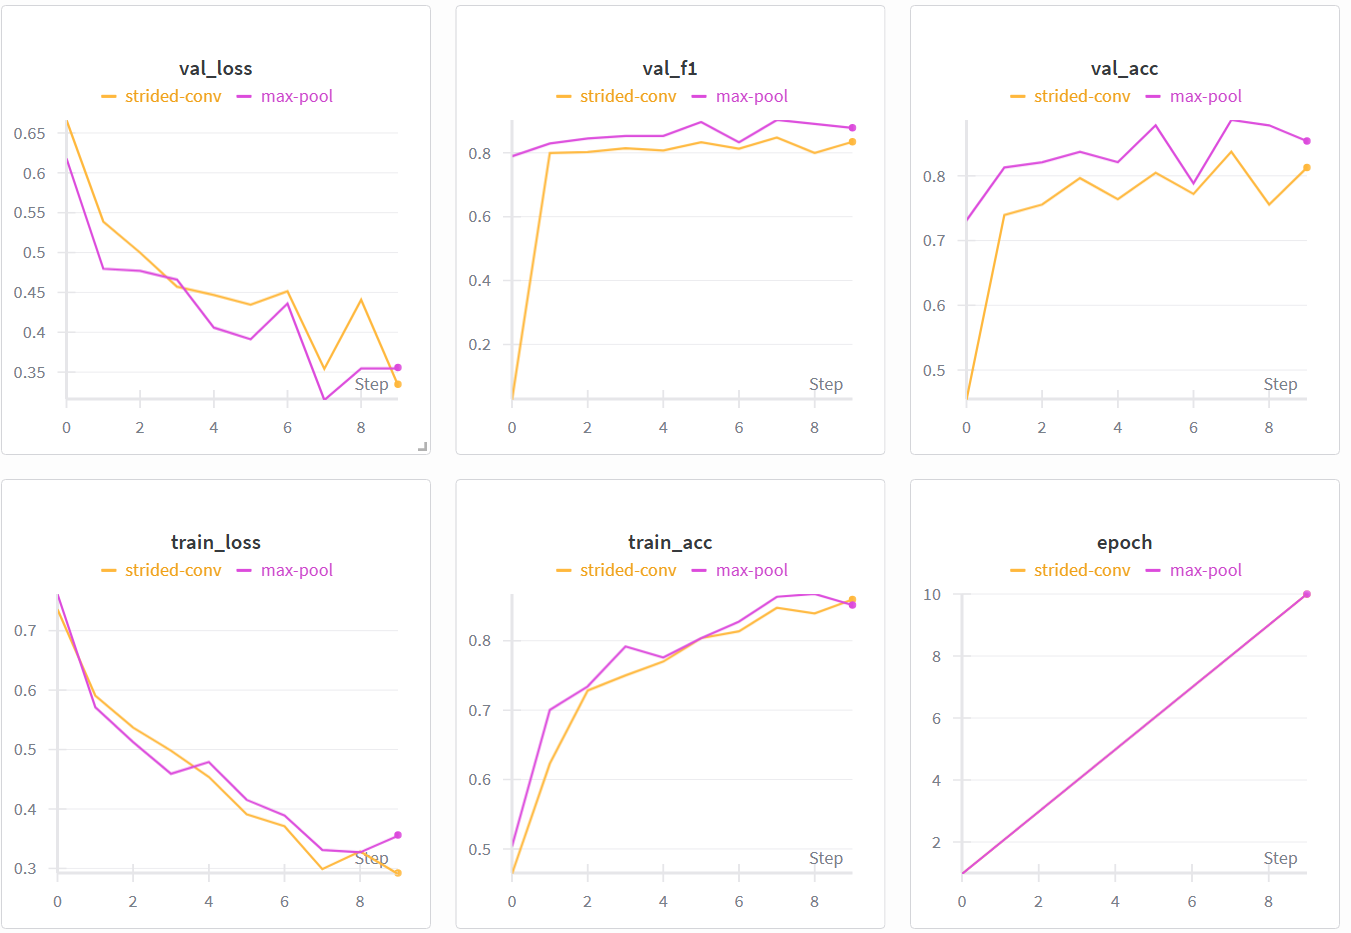

## 7. Written Analysis of Results

**Analysis:**

Looking at it quantitatively, the MaxPool2d baseline achieved a superior F1 score of 0.90 compared to 0.83 for the Strided Convolution model. The validation losses were comparable (0.32 vs 0.33), suggesting that while both models converged, the MaxPool variant generalized better to the specific classification boundary of the validation set.

As expected, the parameter count is the same (1,554,301) for both architecturs. This confirms that replacing a standard convolution + pooling layer with a strided convolution does not introduce new weights.

However, the training time showed a large difference. The Strided Convolution model trained in 27.86s, less than half the time of the MaxPool model (59.89s). This makes sense: in the MaxPool architecture, the convolution operation calculates features for every pixel ($H \times W$) before downsampling. In the Strided architecture the convolution skips pixels.

Theoretically, MaxPool introduces translation invariance and selects the most prominent feature in a window. This likely helps in detecting the sharp geometric edges of the cubes and spheres regardless of slight shifts. On the other hand, strided convolution attempts to learn a weighted downsampling. In this specific synthetic dataset, learning the hard edges via MaxPool looks more beneficial than strided convolutions.

**Recommendation:** Despite the attractive 2x speedup of the Strided Convolution